In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

In [17]:
df = pd.read_csv("Telco-Customer-Churn.csv")
 
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [19]:
df.drop("customerID", axis=1, inplace=True)

In [20]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("NaN in TotalCharges before fill:",
      df["TotalCharges"].isna().sum())

NaN in TotalCharges before fill: 11


In [21]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print("NaN after fill:",
      df["TotalCharges"].isna().sum())

NaN after fill: 0


In [22]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [23]:
# Find current categorical columns
categorical_cols = df.select_dtypes(
    include=['object', 'string', 'category']
).columns.tolist()

print("Categorical Columns Found:")
print(categorical_cols)

# Apply one-hot encoding only if categorical columns exist
if len(categorical_cols) > 0:
    df = pd.get_dummies(
        df,
        columns=categorical_cols,
        drop_first=True
    )

print("New Shape:", df.shape)
df = df.fillna(0)
print("Total NaN values:",
      df.isna().sum().sum())

Categorical Columns Found:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
New Shape: (7043, 31)
Total NaN values: 0


In [24]:
y = df["Churn"]

X = df.drop(columns=["Churn"])

print("X Shape:", X.shape)
print("y Shape:", y.shape)
print("NaN in X:",
      X.isna().sum().sum())

print("NaN in y:",
      y.isna().sum())

X Shape: (7043, 30)
y Shape: (7043,)
NaN in X: 0
NaN in y: 0


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 30)
(1409, 30)


In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
print(
    "NaN in X_train_scaled:",
    np.isnan(X_train_scaled).sum()
)

print(
    "NaN in X_test_scaled:",
    np.isnan(X_test_scaled).sum()
)

NaN in X_train_scaled: 0
NaN in X_test_scaled: 0


In [27]:
lr_model = LogisticRegression(
    max_iter=2000
)

lr_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr_model.predict(
    X_test_scaled
)

y_prob_lr = lr_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1:",
      f1_score(y_test, y_pred_lr))

print("AUC:",
      roc_auc_score(y_test, y_prob_lr))

print("MCC:",
      matthews_corrcoef(y_test, y_pred_lr))

Accuracy: 0.8069552874378992
Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1: 0.6091954022988506
AUC: 0.8415846443979436
MCC: 0.48434401941894756


In [28]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=2000),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "Naive Bayes":
        GaussianNB(),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "SVM":
        SVC(
            probability=True
        )
}

In [29]:
results = []

for name, model in models.items():

    if name in [
        "Logistic Regression",
        "KNN",
        "SVM"
    ]:

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

        y_prob = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )

        y_prob = model.predict_proba(
            X_test
        )[:, 1]

    results.append([
        name,
        round(
            accuracy_score(
                y_test,
                y_pred
            ),4
        ),
        round(
            roc_auc_score(
                y_test,
                y_prob
            ),4
        ),
        round(
            precision_score(
                y_test,
                y_pred
            ),4
        ),
        round(
            recall_score(
                y_test,
                y_pred
            ),4
        ),
        round(
            f1_score(
                y_test,
                y_pred
            ),4
        ),
        round(
            matthews_corrcoef(
                y_test,
                y_pred
            ),4
        )
    ])

In [30]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "AUC",
        "Precision",
        "Recall",
        "F1 Score",
        "MCC"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.8070,0.8416,0.6584,0.5668,0.6092,0.4843
5,SVM,0.7928,0.7960,0.6444,0.4893,0.5562,0.4312
4,Random Forest,0.7899,0.8265,0.6336,0.4947,0.5556,0.4263
2,KNN,0.7473,0.7718,0.5253,0.5000,0.5123,0.3422
1,Decision Tree,0.7417,0.6623,0.5139,0.4947,0.5041,0.3296
3,Naive Bayes,0.6558,0.8096,0.4269,0.8663,0.5719,0.3951


In [33]:
%whos

Variable                 Type                  Data/Info
--------------------------------------------------------
ConfusionMatrixDisplay   type                  <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
DecisionTreeClassifier   ABCMeta               <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GaussianNB               ABCMeta               <class 'sklearn.naive_bayes.GaussianNB'>
KNeighborsClassifier     ABCMeta               <class 'sklearn.neighbors<...>on.KNeighborsClassifier'>
LogisticRegression       type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier   ABCMeta               <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
RocCurveDisplay          type                  <class 'sklearn.metrics._<...>c_curve.RocCurveDisplay'>
SVC                      ABCMeta               <class 'sklearn.svm._classes.SVC'>
StandardScaler           type                  <class 'sklearn.preproces<...>ng._data.StandardScal

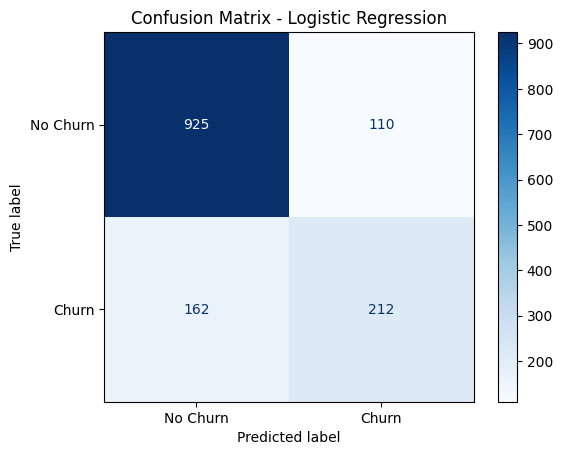

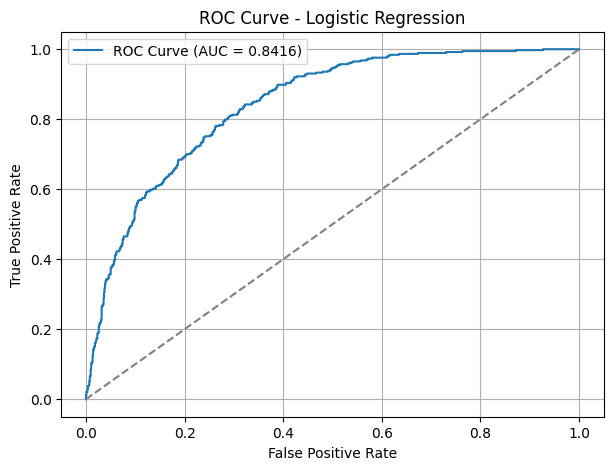


Top 15 Important Features:

                           Feature  Coefficient  AbsCoefficient
25               Contract_Two year    -1.332403        1.332403
10     InternetService_Fiber optic     0.752157        0.752157
24               Contract_One year    -0.684672        0.684672
13              OnlineSecurity_Yes    -0.433978        0.433978
7                 PhoneService_Yes    -0.416625        0.416625
28  PaymentMethod_Electronic check     0.389824        0.389824
19                 TechSupport_Yes    -0.386982        0.386982
26            PaperlessBilling_Yes     0.376350        0.376350
9                MultipleLines_Yes     0.278418        0.278418
6                   Dependents_Yes    -0.223948        0.223948
23             StreamingMovies_Yes     0.207232        0.207232
21                 StreamingTV_Yes     0.205717        0.205717
15                OnlineBackup_Yes    -0.181389        0.181389
8   MultipleLines_No phone service     0.156770        0.156770
0          

In [35]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
import pandas as pd
import matplotlib.pyplot as plt

# =====================================
# 1. CONFUSION MATRIX
# =====================================

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# =====================================
# 2. ROC CURVE
# =====================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_lr
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)

plt.show()

# =====================================
# 3. FEATURE IMPORTANCE
# =====================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

importance["AbsCoefficient"] = abs(
    importance["Coefficient"]
)

importance = importance.sort_values(
    by="AbsCoefficient",
    ascending=False
)

print("\nTop 15 Important Features:\n")
print(importance.head(15))

In [36]:
importance.head(15)

,Feature,Coefficient,AbsCoefficient
25,Contract_Two year,-1.332403,1.332403
10,InternetService_Fiber optic,0.752157,0.752157
24,Contract_One year,-0.684672,0.684672
13,OnlineSecurity_Yes,-0.433978,0.433978
7,PhoneService_Yes,-0.416625,0.416625
28,PaymentMethod_Electronic check,0.389824,0.389824
19,TechSupport_Yes,-0.386982,0.386982
26,PaperlessBilling_Yes,0.376350,0.376350
9,MultipleLines_Yes,0.278418,0.278418
6,Dependents_Yes,-0.223948,0.223948


In [ ]:
Model Performance Analysis

Six machine learning classification models were evaluated for predicting customer churn: Logistic Regression, Decision Tree, K-Nearest Neighbors (KNN), Naive Bayes, Random Forest, and Support Vector Machine (SVM). The models were compared using Accuracy, AUC, Precision, Recall, F1-Score, and Matthews Correlation Coefficient (MCC).

Among all evaluated models, Logistic Regression achieved the best overall performance, with an accuracy of 80.70%, AUC of 0.8416, F1-score of 0.6092, and MCC of 0.4843. These results indicate that Logistic Regression provides the most balanced performance across all evaluation metrics and demonstrates strong capability in distinguishing between churn and non-churn customers.

The confusion matrix shows that the model correctly classified 925 non-churn customers and 212 churn customers, while making relatively few incorrect predictions. The ROC curve further confirms the model's effectiveness, with an AUC of 0.8416, indicating good discriminative ability between the two classes.

Feature importance analysis revealed that Contract Type, Internet Service Type, Online Security, Tech Support, and Payment Method are among the most influential factors affecting customer churn. Customers with one-year and two-year contracts are significantly less likely to churn, whereas customers using fiber-optic internet service and electronic check payment methods tend to have a higher likelihood of churn.

Overall, Logistic Regression provides the best combination of predictive performance, interpretability, and reliability for this customer churn prediction problem.

In [ ]:
Conclusion

The objective of this project was to develop and evaluate machine learning models for predicting customer churn using the Telco Customer Churn dataset. Data preprocessing steps included handling missing values, encoding categorical variables, feature scaling, and splitting the dataset into training and testing sets.

A total of six classification algorithms were implemented and compared. Based on the evaluation metrics, Logistic Regression emerged as the best-performing model, achieving the highest accuracy, AUC, F1-score, and MCC among all models tested. The model demonstrated strong predictive capability while maintaining a good balance between identifying churned customers and minimizing false predictions.

The analysis also identified several important business factors associated with churn, including contract duration, internet service type, online security services, technical support availability, and payment methods. These insights can help organizations better understand customer behavior and implement targeted retention strategies.

In conclusion, the developed Logistic Regression model is an effective and interpretable solution for customer churn prediction. The findings of this study demonstrate the value of machine learning in supporting data-driven decision-making and improving customer retention efforts.